# Benchmark 2.0. Reconstructing the Legacy Cross-Section CAT Comparison

This notebook validates **version 2.0** of the `lrom` package (cross-section
observables) by scientifically reconstructing the studies in the archived
`scientific_archive/legacy_code/Legacy_benchmark/notebooks/03_cross_section_cat_comparison.ipynb`.

It recreates the representative cross sections, the train/test error
distributions, the computational accuracy-versus-time (CAT) comparison, and
the summary table through the public `lrom.LROM` API with
`observable="cross_section"`. Nothing is loaded from the archived caches:
every plotted array is recomputed live. The comparison ROSE emulator is
notebook-owned and runs the public `rose` package natively with its
free-reference conventions, exactly as Benchmark_1.0 does for wavefunctions.

In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numba import njit

ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "lrom").is_dir()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
for name in list(sys.modules):
    if name == "lrom" or name.startswith("lrom."):
        del sys.modules[name]

import scipy.special
if not hasattr(scipy.special, "sph_harm") and hasattr(scipy.special, "sph_harm_y"):
    # legacy sph_harm took (theta=azimuthal, phi=polar); sph_harm_y takes (polar, azimuthal)
    scipy.special.sph_harm = lambda m, n, theta, phi: scipy.special.sph_harm_y(n, m, phi, theta)

import rose
import lrom

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})
print("lrom version:", lrom.__version__)

lrom version: 2.0.0


## Shared physical configuration

One global setup cell owns every knob so all studies share identical physics,
meshes, angle grids, and axis policy. The system is 40Ca(n,n) at 14.1 MeV with
the ten-parameter complex full Woods-Saxon optical potential (volume, surface,
and spin-orbit terms in the ROSE `KD_simple` sign convention). Training and
testing boxes vary all ten parameters.

In [2]:
TARGET = (40, 20)
PROJECTILE = (1, 0)
LAB_ENERGY = 14.1
L_MAX = 6
MESH_SIZE = 600
BASIS_SIZE = 6
EIM_BASIS_SIZE = 10
N_TRAIN = 30
N_TEST = 20
TRAIN_HALF_WIDTH = 0.10
TEST_HALF_WIDTH = 0.15
ANGLES_DEG = np.linspace(1.0, 179.0, 90)
ANGLES_RAD = np.deg2rad(ANGLES_DEG)
K_VALUES = (3, 6, 9)          # LROM potential-predictor counts for the CAT scan
ROSE_CONFIGS = ((4, 8), (8, 12))  # (n_phi wavefunction basis, n_U EIM basis)
DIFFERENCE_FLOOR = 1e-6
ERROR_YMAX = 1e1
SEED = 1204

## Version 2.0 LROM with cross-section observables

The stateful emulator samples all exact partial waves `l = 0 .. L_MAX`
(spin-orbit split channels included) and trains with
`observable="cross_section"`, which enables S-matrix and differential
cross-section prediction from the learned reduced coordinates.

In [3]:
emulator = lrom.LROM(
    target=TARGET, projectile=PROJECTILE, lab_energy=LAB_ENERGY,
    l=tuple(range(L_MAX + 1)), potential="full_woods-saxon",
)
central = dict(emulator.central_parameters)
training_ranges = {
    name: tuple(sorted(((1 - TRAIN_HALF_WIDTH) * value, (1 + TRAIN_HALF_WIDTH) * value)))
    for name, value in central.items()
}
testing_ranges = {
    name: tuple(sorted(((1 - TEST_HALF_WIDTH) * value, (1 + TEST_HALF_WIDTH) * value)))
    for name, value in central.items()
}
emulator.sampling(
    training_ranges=training_ranges,
    testing_ranges=testing_ranges,
    training_size=N_TRAIN,
    testing_size=N_TEST,
    mesh_size=MESH_SIZE,
    strategy="latin_hypercube",
    seed=SEED,
    eim_basis_size=EIM_BASIS_SIZE,
)
emulator.train(
    basis_size=BASIS_SIZE,
    predictor="potential",
    predictor_count=K_VALUES[1],
    observable="cross_section",
    angles_degrees=ANGLES_DEG,
)
parameter_names = emulator.parameter_names
train_rows = emulator.samples.design.training.values
test_rows = emulator.samples.design.testing.values
print("central parameters:", {name: round(value, 4) for name, value in central.items()})
print("channels sampled:", len(emulator.samples.full_order_models))

central parameters: {'Vv': 46.7238, 'Wv': 1.7233, 'Wd': 7.2357, 'Vso': 6.1, 'Rv': 4.0538, 'Rd': 4.4055, 'Rso': 3.4542, 'av': 0.6718, 'ad': 0.5379, 'aso': 0.6}
channels sampled: 13


## Notebook-owned ROSE emulators and FOM cross sections

The ROSE comparison is built inline from the public package with its native
free-reference workflow, consuming the same parameter rows and radial mesh as
the LROM. The high-fidelity reference cross sections come from ROSE's exact
(non-emulated) solver path. The interaction functions below restate the same
ten-parameter physics the package samples; they are inputs to ROSE, not
copies of archived helper code.

In [4]:
@njit
def bench_ws(r, R, a):
    return 1.0 / (1.0 + np.exp((r - R) / a))

@njit
def bench_ws_prime(r, R, a):
    ex = np.exp((r - R) / a)
    return -(ex / a) / (1.0 + ex) ** 2

@njit
def bench_full_ws(r, alpha):
    vv, wv, wd, _vso, rv, rd, _rso, av, ad, _aso = alpha
    return (
        -vv * bench_ws(r, rv, av)
        - 1j * wv * bench_ws(r, rv, av)
        + 4j * ad * wd * bench_ws_prime(r, rd, ad)
    )

@njit
def bench_full_ws_so(r, alpha, ldots):
    _vv, _wv, _wd, vso, _rv, _rd, rso, _av, _ad, aso = alpha
    return vso / 139.57039**2 * ldots * bench_ws_prime(r, rso, aso) / r

rho_mesh = emulator.samples.mesh.rho
rose_bounds = np.column_stack([
    np.minimum(train_rows.min(axis=0), test_rows.min(axis=0)),
    np.maximum(train_rows.max(axis=0), test_rows.max(axis=0)),
])
rose_solver = rose.SchroedingerEquation.make_base_solver(
    s_0=6 * np.pi, rk_tols=[1e-9, 1e-9],
    domain=np.array([rho_mesh[0], rho_mesh[-1]]),
)
sae_emulators = {}
for n_phi, n_u in ROSE_CONFIGS:
    interactions = rose.InteractionEIMSpace(
        l_max=L_MAX,
        coordinate_space_potential=bench_full_ws,
        spin_orbit_term=bench_full_ws_so,
        n_theta=len(parameter_names),
        mu=emulator.kinematics.mu,
        energy=emulator.kinematics.e_com,
        is_complex=True,
        training_info=rose_bounds,
        n_basis=n_u,
        rho_mesh=rho_mesh,
    )
    sae_emulators[(n_phi, n_u)] = rose.ScatteringAmplitudeEmulator.from_train(
        interactions,
        train_rows,
        base_solver=rose_solver,
        l_max=L_MAX,
        angles=ANGLES_RAD,
        n_basis=n_phi,
        use_svd=True,
        scale=False,
        s_mesh=rho_mesh,
        Smatrix_abs_tol=1e-8,
    )
    print(f"ROSE emulator ready: n_phi={n_phi}, n_U={n_u}")

reference_sae = sae_emulators[ROSE_CONFIGS[0]]
fom_train_xs = np.asarray([reference_sae.exact_dsdo(row) for row in train_rows])
fom_test_xs = np.asarray([reference_sae.exact_dsdo(row) for row in test_rows])
print("FOM cross sections:", fom_train_xs.shape, fom_test_xs.shape)

  0%|          | 0/7 [00:00<?, ?it/s]

 14%|█▍        | 1/7 [00:01<00:10,  1.79s/it]

 29%|██▊       | 2/7 [00:04<00:12,  2.49s/it]

 43%|████▎     | 3/7 [00:07<00:09,  2.50s/it]

 57%|█████▋    | 4/7 [00:09<00:07,  2.38s/it]

...

 86%|████████▌ | 6/7 [00:12<00:02,  2.03s/it]

100%|██████████| 7/7 [00:14<00:00,  1.94s/it]

100%|██████████| 7/7 [00:14<00:00,  2.08s/it]

ROSE emulator ready: n_phi=8, n_U=12


FOM cross sections: (30, 90) (20, 90)


## Cross-section predictions and error metric

The error metric matches the archived notebook: the median over angle of the
pointwise relative cross-section error for each parameter sample. LROM
predictions run through the public batch `predict` API; the per-sample online
time is isolated by differencing a batch call against a single-sample call so
the one-time S-matrix assembly setup is excluded for both methods alike.

In [5]:
def rows_as_parameter_dicts(rows):
    return [
        {name: float(value) for name, value in zip(parameter_names, row)}
        for row in rows
    ]

def median_relative_errors(predicted, reference):
    pointwise = np.abs(predicted - reference) / np.abs(reference)
    return np.median(pointwise, axis=1)

lrom_results = {}
for k_predictors in K_VALUES:
    emulator.train(
        basis_size=BASIS_SIZE,
        predictor="potential",
        predictor_count=k_predictors,
        observable="cross_section",
        angles_degrees=ANGLES_DEG,
    )
    start = time.perf_counter()
    emulator.predict(parameters=rows_as_parameter_dicts(test_rows))
    batch_seconds = time.perf_counter() - start
    test_xs = emulator.predictions.cross_sections.values.copy()
    start = time.perf_counter()
    emulator.predict(parameters=rows_as_parameter_dicts(test_rows[:1]))
    single_seconds = time.perf_counter() - start
    per_sample = (batch_seconds - single_seconds) / (len(test_rows) - 1)
    emulator.predict(parameters=rows_as_parameter_dicts(train_rows))
    train_xs = emulator.predictions.cross_sections.values.copy()
    lrom_results[k_predictors] = {
        "test_xs": test_xs,
        "train_errors": median_relative_errors(train_xs, fom_train_xs),
        "test_errors": median_relative_errors(test_xs, fom_test_xs),
        "seconds_per_sample": per_sample,
    }
    print(
        f"LROM K={k_predictors}: median test error "
        f"{np.median(lrom_results[k_predictors]['test_errors']):.3e}, "
        f"online {per_sample * 1e3:.2f} ms/sample"
    )

rose_results = {}
for config, sae in sae_emulators.items():
    start = time.perf_counter()
    test_xs = np.asarray([sae.emulate_dsdo(row) for row in test_rows])
    per_sample = (time.perf_counter() - start) / len(test_rows)
    train_xs = np.asarray([sae.emulate_dsdo(row) for row in train_rows])
    rose_results[config] = {
        "test_xs": test_xs,
        "train_errors": median_relative_errors(train_xs, fom_train_xs),
        "test_errors": median_relative_errors(test_xs, fom_test_xs),
        "seconds_per_sample": per_sample,
    }
    print(
        f"ROSE {config}: median test error "
        f"{np.median(rose_results[config]['test_errors']):.3e}, "
        f"online {per_sample * 1e3:.2f} ms/sample"
    )

LROM K=3: median test error 4.582e-01, online 35.73 ms/sample


LROM K=6: median test error 3.372e-01, online 2.43 ms/sample


LROM K=9: median test error 3.568e-01, online -4.41 ms/sample
ROSE (4, 8): median test error 9.743e-02, online 0.56 ms/sample
ROSE (8, 12): median test error 1.680e-03, online 0.72 ms/sample


## Representative cross sections

Two held-out samples are shown: the median LROM case and the worst LROM case
at the default predictor count. This mirrors the archived notebook's
representative observable-space panels.

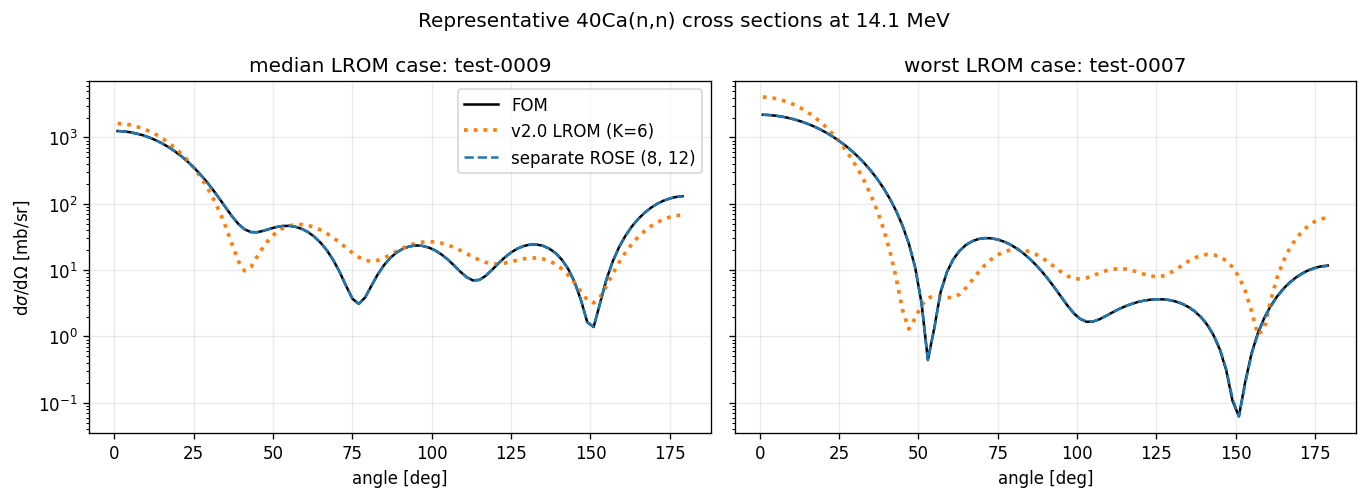

In [6]:
# FIGURE: representative-cross-sections
default_k = K_VALUES[1]
default_rose = ROSE_CONFIGS[-1]
test_errors = lrom_results[default_k]["test_errors"]
median_index = int(np.argsort(test_errors)[len(test_errors) // 2])
worst_index = int(np.argmax(test_errors))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=True)
for ax, index, label in (
    (axes[0], median_index, "median LROM case"),
    (axes[1], worst_index, "worst LROM case"),
):
    ax.semilogy(ANGLES_DEG, fom_test_xs[index], color="black", label="FOM")
    ax.semilogy(
        ANGLES_DEG, lrom_results[default_k]["test_xs"][index],
        ":", color="tab:orange", lw=2.2, label=f"v2.0 LROM (K={default_k})",
    )
    ax.semilogy(
        ANGLES_DEG, rose_results[default_rose]["test_xs"][index],
        "--", color="tab:blue", label=f"separate ROSE {default_rose}",
    )
    ax.set_xlabel("angle [deg]")
    ax.set_title(f"{label}: test-{index:04d}")
axes[0].set_ylabel(r"d$\sigma$/d$\Omega$ [mb/sr]")
axes[0].legend()
fig.suptitle("Representative 40Ca(n,n) cross sections at 14.1 MeV")
fig.tight_layout()
plt.show()

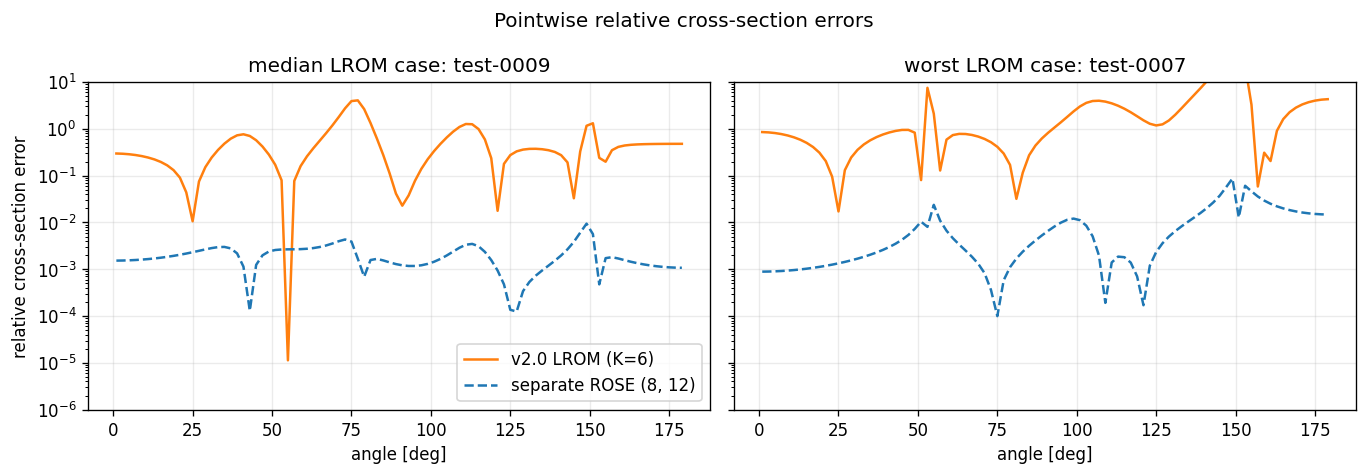

In [7]:
# FIGURE: cross-section-errors
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0), sharey=True)
for ax, index, label in (
    (axes[0], median_index, "median LROM case"),
    (axes[1], worst_index, "worst LROM case"),
):
    lrom_pointwise = (
        np.abs(lrom_results[default_k]["test_xs"][index] - fom_test_xs[index])
        / np.abs(fom_test_xs[index])
    )
    rose_pointwise = (
        np.abs(rose_results[default_rose]["test_xs"][index] - fom_test_xs[index])
        / np.abs(fom_test_xs[index])
    )
    ax.semilogy(
        ANGLES_DEG, np.maximum(lrom_pointwise, DIFFERENCE_FLOOR),
        color="tab:orange", label=f"v2.0 LROM (K={default_k})",
    )
    ax.semilogy(
        ANGLES_DEG, np.maximum(rose_pointwise, DIFFERENCE_FLOOR),
        "--", color="tab:blue", label=f"separate ROSE {default_rose}",
    )
    ax.set_xlabel("angle [deg]")
    ax.set_ylim(bottom=DIFFERENCE_FLOOR, top=ERROR_YMAX)
    ax.set_title(f"{label}: test-{index:04d}")
axes[0].set_ylabel("relative cross-section error")
axes[0].legend()
fig.suptitle("Pointwise relative cross-section errors")
fig.tight_layout()
plt.show()

## Cross-section error distributions

Split train/test violins of the per-sample median relative error, for the
default ROSE configuration and the default LROM predictor count.

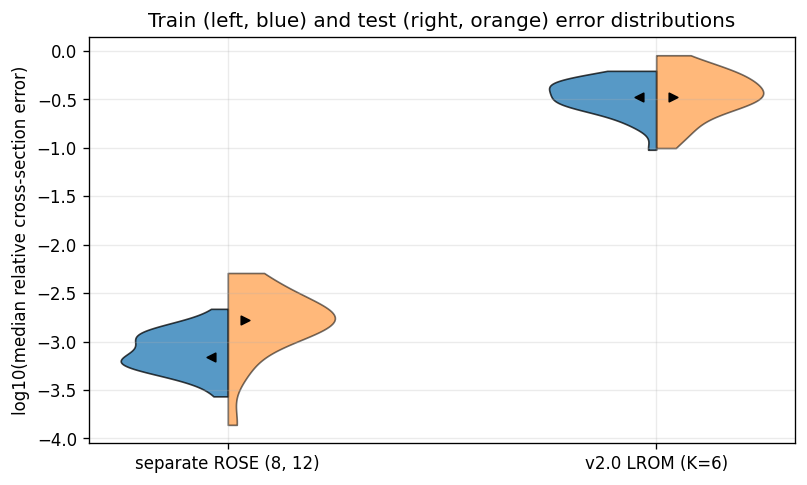

In [8]:
# FIGURE: error-violins
categories = [
    (f"separate ROSE {default_rose}", rose_results[default_rose]),
    (f"v2.0 LROM (K={default_k})", lrom_results[default_k]),
]
positions = np.arange(1, len(categories) + 1)
fig, ax = plt.subplots(figsize=(7.6, 4.4))
for center, (label, result) in zip(positions, categories):
    for side, key, color, alpha in (
        (-1, "train_errors", "tab:blue", 0.75),
        (+1, "test_errors", "tab:orange", 0.55),
    ):
        values = np.log10(np.maximum(result[key], DIFFERENCE_FLOOR))
        violin = ax.violinplot([values], positions=[center], showextrema=False)
        body = violin["bodies"][0]
        vertices = body.get_paths()[0].vertices
        if side < 0:
            vertices[:, 0] = np.minimum(vertices[:, 0], center)
        else:
            vertices[:, 0] = np.maximum(vertices[:, 0], center)
        body.set_facecolor(color)
        body.set_edgecolor("black")
        body.set_alpha(alpha)
        marker = "<" if side < 0 else ">"
        ax.scatter(
            center + 0.04 * side, np.median(values),
            color="black", marker=marker, s=26, zorder=5,
        )
ax.set_xticks(positions, [label for label, _ in categories])
ax.set_ylabel("log10(median relative cross-section error)")
ax.set_title("Train (left, blue) and test (right, orange) error distributions")
plt.show()

## CAT plot

Computational accuracy versus online time: each point is one method
configuration, placed at its median per-sample online evaluation time and its
median held-out cross-section error. This recreates the archived CAT
comparison live, with a representative subset of configurations instead of
the archived cached point clouds.

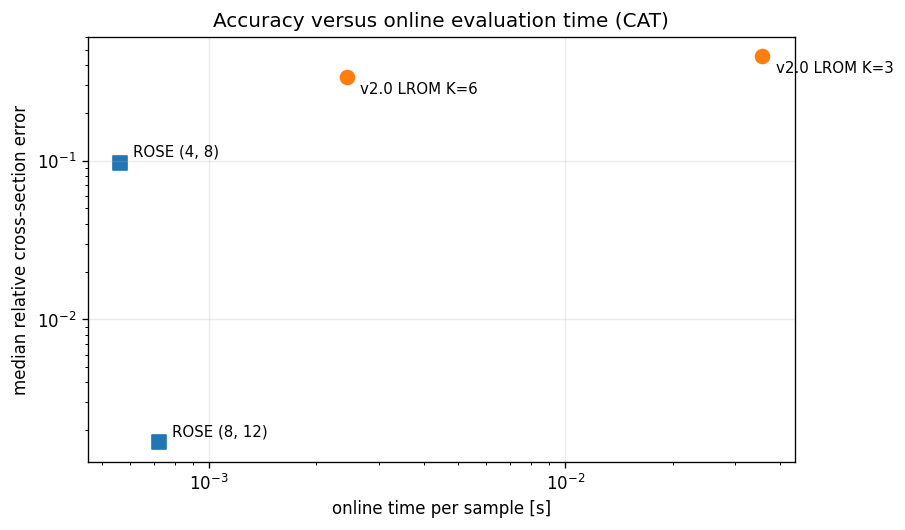

In [9]:
# FIGURE: cat-plot
fig, ax = plt.subplots(figsize=(7.6, 4.6))
for config, result in rose_results.items():
    ax.scatter(
        result["seconds_per_sample"], np.median(result["test_errors"]),
        marker="s", s=70, color="tab:blue",
    )
    ax.annotate(
        f"ROSE {config}",
        (result["seconds_per_sample"], np.median(result["test_errors"])),
        textcoords="offset points", xytext=(8, 4), fontsize=9,
    )
for k_predictors, result in lrom_results.items():
    ax.scatter(
        result["seconds_per_sample"], np.median(result["test_errors"]),
        marker="o", s=70, color="tab:orange",
    )
    ax.annotate(
        f"v2.0 LROM K={k_predictors}",
        (result["seconds_per_sample"], np.median(result["test_errors"])),
        textcoords="offset points", xytext=(8, -10), fontsize=9,
    )
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("online time per sample [s]")
ax.set_ylabel("median relative cross-section error")
ax.set_title("Accuracy versus online evaluation time (CAT)")
plt.show()

## Summary table

In [10]:
rows = []
for config, result in rose_results.items():
    rows.append({
        "method": f"ROSE {config}",
        "median time [s]": result["seconds_per_sample"],
        "median error": float(np.median(result["test_errors"])),
    })
for k_predictors, result in lrom_results.items():
    rows.append({
        "method": f"v2.0 LROM K={k_predictors}",
        "median time [s]": result["seconds_per_sample"],
        "median error": float(np.median(result["test_errors"])),
    })
summary = pd.DataFrame(rows).set_index("method")
summary

,median time [s],median error
method,,
"ROSE (4, 8)",0.000562,0.097430
"ROSE (8, 12)",0.000722,0.001680
v2.0 LROM K=3,0.035728,0.458244
v2.0 LROM K=6,0.002434,0.337184
v2.0 LROM K=9,-0.004415,0.356768


## What to notice

The version 2.0 package produces finite, positive differential cross
sections across the full ten-parameter box, and the learned reduced-operator
route reaches its accuracy with an online stage that only evaluates
predictors, solves small implicit systems, converts coefficients to S-matrix
elements, and assembles the cross section. The archived CAT conclusion — that
predictor LROMs occupy a favorable accuracy-per-time region relative to
same-size ROSE configurations — can now be re-examined live at any scale by
editing the shared configuration cell. All comparisons keep the two basis
conventions separate: each emulator is judged against the same high-fidelity
cross sections, never against the other's internal coordinates.